In [1]:
import joblib
import pandas as pd

model = joblib.load("../models/best_model.pkl")
X_train = pd.read_csv("../data/processed/X_train.csv")


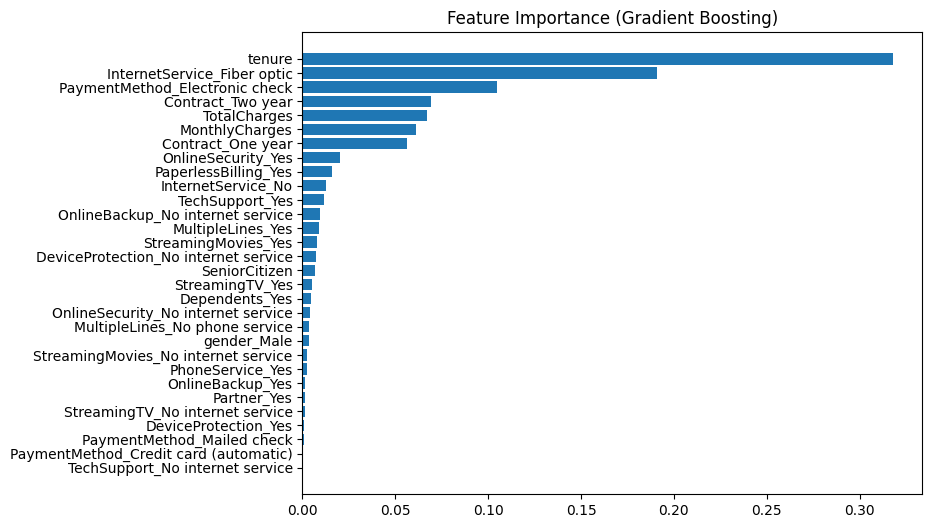

In [2]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(X_train.columns[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance (Gradient Boosting)")
plt.show()


In [12]:
feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_df.head(10)


,feature,importance
1,tenure,0.317935
10,InternetService_Fiber optic,0.190840
28,PaymentMethod_Electronic check,0.104797
25,Contract_Two year,0.069253
3,TotalCharges,0.067267
2,MonthlyCharges,0.061198
24,Contract_One year,0.056428
13,OnlineSecurity_Yes,0.019964
26,PaperlessBilling_Yes,0.015879
11,InternetService_No,0.012878


In [13]:
feat_df.to_csv("../data/processed/feature_importance.csv", index=False)


In [ ]:

y_proba_train = model.predict_proba(X_train)[:, 1]
risk_df = pd.DataFrame({
    "churn_probability": y_proba_train
})
risk_df.to_csv("../data/processed/churn_risk_raw.csv", index=False)
print("Saved churn risk probabilities to ../data/processed/churn_risk_raw.csv")


Saved churn risk probabilities to ../data/processed/churn_risk_raw.csv


## 📌 Key Drivers of Customer Churn 

Based on Gradient Boosting feature importance:

1. Customers on **month-to-month contracts** are most likely to churn.
2. Customers with **high monthly charges** tend to churn more.
3. Low tenure customers (recent sign-ups) churn at higher rates.
4. Lack of technical support and online security services increases churn.
5. Customers using **electronic check** payment method show higher churn.

## 📍 Business Implications

- Incentivize customers to move to annual contracts.
- Target new customers early in their lifecycle with retention offers.
- Review pricing strategy for high-charge segments.
- Bundle security/tech support services at a discount.
- Encourage auto-pay or card payment methods to reduce churn friction.
